# Heracles

In [1]:
import jax
import jax.numpy as jnp
from eleanor.models import Heracles
import matplotlib.pyplot as plt
import snnax.snn as snn

In [22]:
t = jnp.linspace(0, 1, 100).reshape(100, 1)
input = jnp.cos(8 * t)
input = 50e-12 * jnp.sign(input) * (input > 0.5)
felif = snn.Sequential(Heracles(dt=1e-3, paramsScale=1.0, key=None))
state = felif.init_state((1,), jax.random.key(0))
_, outs = felif(state, input, key=jax.random.key(0))
s_ms = outs[0][0]
v_ms = outs[0][1]
p_ms = outs[0][2]
c_ms = outs[0][3]

t_us = jnp.linspace(0, 1, 100000).reshape(100000, 1)
input_us = jnp.cos(8 * t_us)
input_us = 50e-12 * jnp.sign(input_us) * (input_us > 0.5)
felif = snn.Sequential(Heracles(dt=1e-6, paramsScale=1.0, key=None))
state = felif.init_state((1,), jax.random.key(0))
_, outs = felif(state, input_us, key=jax.random.key(0))
s_us = outs[0][0]
v_us = outs[0][1]
p_us = outs[0][2]
c_us = outs[0][3]

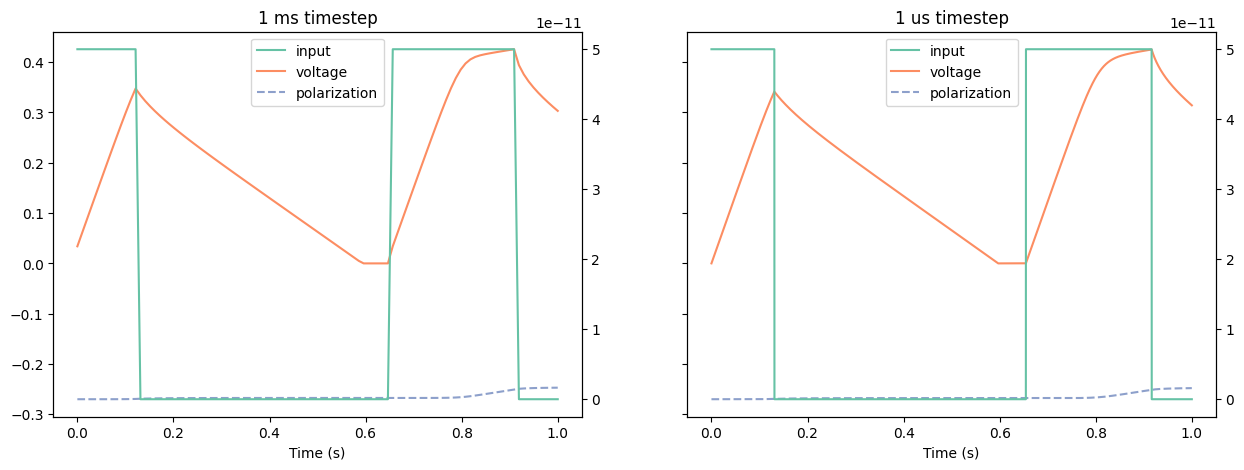

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
ax = axs[0].twinx()
lns1 = ax.plot(t, input, c="#66c2a5", label="input")
lns2 = axs[0].plot(t, v_ms, c="#fc8d62", label="voltage")
lns3 = axs[0].plot(t, p_ms, "--", c="#8da0cb", label="polarization")

# added these three lines
lns = lns1 + lns2 + lns3
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc=0)
axs[0].set_xlabel("Time (s)")
axs[0].set_title("1 ms timestep")

ax = axs[1].twinx()
lns1 = ax.plot(t_us, input_us, c="#66c2a5", label="input")
lns2 = axs[1].plot(t_us, v_us, c="#fc8d62", label="voltage")
lns3 = axs[1].plot(t_us, p_us, "--", c="#8da0cb", label="polarization")

# added these three lines
lns = lns1 + lns2 + lns3
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc=0)
axs[1].set_xlabel("Time (s)")
axs[1].set_title("1 us timestep")
plt.show()